# Plánování kritické cesty pro uvedení produktu autopojištění

## Manažerské shrnutí

Uvedení produktu osobního autopojištění je meziútvarový program: pojistní matematici oceňují riziko, oddělení compliance podává sazby státnímu regulátorovi a čeká na schválení, IT konfiguruje systém správy pojistných smluv a distribuce školí agenty. Tyto úkoly mají pevné vztahy návaznosti, takže datum uvedení je určeno nejdelším řetězcem závislostí napříč plánem -- **kritickou cestou**.

Tento notebook sestaví projektovou síť typu Activity-on-Node z jedenácti úkolů uvedení a spočítá kompletní rozvrh metodou **kritické cesty (CPM)** pomocí **PROC OPTMODEL**. Dopředný a zpětný průchod CPM jsou lineární programy nad grafem návazností: dopředný průchod (nejdelší cesta od začátku) dává každému úkolu nejdřívější začátek a konec a zpětný průchod nejdelší cestou dává nejpozdější začátek a konec a **celkovou rezervu** (časovou vůli rozvrhu). Níže uvedené výsledky jsou zcela vytvořeny kódem v tomto notebooku -- každé číslo v textu je zpětně načteno ze spuštěného výstupu.

**Co rozvrh ukazuje.** Na pětidenním pracovním kalendáři ukotveném k 01JUN2026 program trvá **97 pracovních dní** a končí **13OCT2026**. Devět z jedenácti úkolů leží na kritické cestě (Kickoff -> Market research -> Loss-data assembly -> Pricing -> System design -> System build -> UAT -> Agent training -> Launch) a nesou nulovou rezervu. Pouze regulatorní větev -- **rate filing** a **approval** -- má vůli: každá se může opozdit až o **30 pracovních dní**, aniž by posunula uvedení, protože paralelní větev sestavení systému je delší ze dvou sbíhajících se cest.

## Jak je to postaveno

CPM je klasicky procedura ze SAS/OR, ale její jádrový výpočet tvoří dvojice úloh o nejdelší cestě v grafu návazností, kterou PROC OPTMODEL vyjadřuje přímo jako malé lineární programy:

- **Dopředný průchod (nejdřívější časy).** Minimalizuje proměnné nejdřívějšího začátku za podmínky `ES[successor] >= ES[predecessor] + duration + lag` pro každou hranu návaznosti. V optimu se každé `ES` rovná nejdelší cestě od začátku projektu, tj. nejdřívějšímu okamžiku, kdy úkol může začít.
- **Zpětný průchod (nejpozdější časy / rezerva).** Pro každý úkol spočítá nejdelší zbývající cestu do konce projektu (`TAIL`). Nejpozdější začátek je pak `makespan - TAIL` a **celková rezerva** je `nejpozdější začátek - nejdřívější začátek`. Úkoly s nulovou rezervou jsou kritické.

Síť, doby trvání, prodlevy návazností a zdrojové nároky jednotlivých úkolů jsou generovány přímo v kódu; nejsou žádné externí vstupy. Kalendářní data pracovních dní jsou odvozena pomocí `INTNX('weekday', ...)`, takže víkendy jsou přeskočeny.

## Data

| Datová sada | Řádky | Klíčové proměnné | Popis |
|---------|------|---------------|-------------|
| `acts`  | 11 | `id`, `activity`, `dur`, `actuary`, `developer` | Číselník aktivit: každý úkol uvedení, jeho doba trvání v pracovních dnech a denní počet pojistných matematiků / vývojářů, který vyžaduje |
| `arcs`  | 12 | `pred`, `succ`, `lag` | Hrany návaznosti sítě Activity-on-Node; `lag` je prodleva typu finish-to-start v pracovních dnech (regulatorní čekací lhůta po schválení) |

Číselná ID aktivit tvoří klíč sítě, takže graf návazností se čistě načte do množiny n-tic v OPTMODEL; čitelné názvy `activity` jsou k rozvrhu připojeny zpět následně.

In [1]:
data acts;
   DÉLKA activity $20;
   VSTUP id activity $ dur actuary developer;
   DATALINES;
1 Zahájení 3 1 0
2 PrůzkumTrhu 8 2 0
3 DataŠkod 10 3 0
4 Oceňování 9 3 1
5 PodáníSazeb 4 1 0
6 Schválení 6 1 0
7 NávrhSystému 12 1 2
8 StavbaSystému 18 0 3
9 UAT 15 0 2
10 ŠkoleníAgentů 20 1 1
11 Spuštění 2 1 1
;
SPUSTIT;

data arcs;
   VSTUP pred succ lag;
   DATALINES;
1 2 0
2 3 0
3 4 0
4 5 0
4 7 0
5 6 0
6 10 5
7 8 0
8 9 0
9 10 0
9 11 0
10 11 0
;
SPUSTIT;

/* čistě číselný pohled na trvání pro OPTMODEL */
data acts_n; NASTAVIT acts; PONECHAT id dur; SPUSTIT;


NOTE: DATA acts

NOTE: Processing inline DATALINES (11 lines)

NOTE: Read 11 rows from DATALINES.
NOTE: Wrote acts (11 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA arcs

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote arcs (12 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA acts_n


NOTE: Read 11 rows from acts.
NOTE: Wrote acts_n (11 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Dopředný průchod -- nejdřívější začátek a konec

Dopředný průchod je LP o nejdelší cestě. Podmínka `ES[j] >= ES[i] + dur[i] + lag[i,j]` pro každou hranu vynucuje, aby každý úkol začal nejdříve poté, co skončí všichni jeho předchůdci (plus případná regulatorní prodleva); minimalizace proměnných nejdřívějšího začátku přivede každou z nich na nejdelší cestu předchůdců. Vyřešené hodnoty `ES` zapisujeme přímo z proměnné OPTMODEL do `fwd`.

In [2]:
PROCEDURA optmodel;
   NASTAVIT NODES; num dur{NODES};
   READ data acts_n INTO NODES=[id] dur=dur;

   NASTAVIT <num,num> ARCS; num lag{ARCS};
   READ data arcs INTO ARCS=[pred succ] lag=lag;

   PROMĚNNÁ ES{NODES} >= 0;
   con prec{<i,j> IN ARCS}:
       ES[j] >= ES[i] + dur[i] + lag[i,j];
   MIN total_es = sum{k IN NODES} ES[k];
   solve;

   CREATE data fwd FROM [id]=NODES es=ES;
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_ES
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         12

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_ES
  Solution Status               Optimal
  Objective Value               401.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Zpětný průchod -- nejpozdější časy a celková rezerva

`TAIL[a]` je nejdelší cesta z úkolu `a` až do konce projektu, takže musí pokrýt vlastní dobu trvání úkolu a pro každého následníka prodlevu plus tail tohoto následníka: `TAIL[i] >= dur[i] + lag[i,j] + TAIL[j]`. Minimalizace tailů dává nejtěsnější takové hodnoty. **Makespan** projektu je největší nejdřívější konec; **nejpozdější začátek** každého úkolu je `makespan - TAIL` a **celková rezerva** je `nejpozdější začátek - nejdřívější začátek`. Nulová rezerva označuje kritickou cestu.

In [3]:
PROCEDURA optmodel;
   NASTAVIT NODES; num dur{NODES};
   READ data acts_n INTO NODES=[id] dur=dur;

   NASTAVIT <num,num> ARCS; num lag{ARCS};
   READ data arcs INTO ARCS=[pred succ] lag=lag;

   PROMĚNNÁ TAIL{NODES} >= 0;
   con BASE{a IN NODES}: TAIL[a] >= dur[a];
   con back{<i,j> IN ARCS}:
       TAIL[i] >= dur[i] + lag[i,j] + TAIL[j];
   MIN total_tail = sum{k IN NODES} TAIL[k];
   solve;

   CREATE data bwd FROM [id]=NODES tail=TAIL;
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_TAIL
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         23

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_TAIL
  Solution Status               Optimal
  Objective Value               606.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Sestavení rozvrhu a kalendáře

Připojíme nejdřívější začátky a taily zpět k číselníku aktivit, odvodíme nejpozdější začátek / konec a celkovou rezervu a namapujeme posuny v pracovních dnech na kalendářní data pomocí `INTNX('weekday', ...)`, aby data padla na pracovní dny. Úkol je označen jako **kritický**, když je jeho celková rezerva nulová.

In [4]:
%LET anchor = '01jun2026'd;

data sched0;
   SLOUČIT acts fwd bwd; PODLE id;
   ef = es + dur;            /* nejdřívější konec */
SPUSTIT;

PROCEDURA PRŮMĚRY data=sched0 NOPRINT;
   VÝSTUP out=mk(ODSTRANIT=_type_ _freq_) MAX(ef)=makespan;
SPUSTIT;

data sched;
   KDYŽ _n_=1 PAK NASTAVIT mk;
   NASTAVIT sched0;
   UCHOVAT mspan;
   KDYŽ _n_=1 PAK mspan = makespan;
   ls = mspan - tail;        /* nejpozdější začátek */
   lf = ls + dur;            /* nejpozdější konec   */
   tfloat = ls - es;         /* celková rezerva     */
   e_start  = intnx('weekday', &anchor, es,   'b');
   e_finish = intnx('weekday', &anchor, ef-1, 'b');
   l_start  = intnx('weekday', &anchor, ls,   'b');
   l_finish = intnx('weekday', &anchor, lf-1, 'b');
   critical = (round(tfloat,1e-6)=0);
   DÉLKA cclass $12;
   KDYŽ critical PAK cclass='Kritická';
   JINAK cclass='Rezerva';
   FORMÁT e_start e_finish l_start l_finish date9.;
SPUSTIT;

PROCEDURA ŘADIT data=sched out=sched_es; PODLE es id; SPUSTIT;


NOTE: DATA sched0

NOTE: Stream 1 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 11 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote sched0 (11 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mk has 1 observations and 1 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA sched


NOTE: Read 11 rows from sched0.
NOTE: Wrote sched (11 rows, 19 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=sched

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 11 rows from sched.
NOTE: Wrote sched_es (11 rows, 19 columns).
NOTE: PROC SORT statement used.


## Rozvrh CPM

Nejdřívější/nejpozdější začátek a konec jsou v pracovních dnech od kotvy 01JUN2026 (den 0). Úkoly ve třídě **Critical** mají nulovou celkovou rezervu.

In [5]:
NÁZEV 'Rozvrh CPM -- časy v pracovních dnech a celková rezerva';
PROCEDURA TISK data=sched_es noobs ŠTÍTEK;
   PROMĚNNÁ activity dur es ef ls lf tfloat cclass;
   ŠTÍTEK activity='Aktivita' dur='Trvání (dny)' es='NZ' ef='NK'
         ls='PZ' lf='PK' tfloat='Celk. rezerva' cclass='Třída';
SPUSTIT;

                                Rozvrh CPM -- časy v pracovních dnech a celková rezerva                                 


        Aktivita    Trvání (dny)  NZ  NK  PZ  PK  Celk. rezerva      Třída
----------------  --------------  --  --  --  --  -------------  ---------
Zahájení                       3   0   3   0   3              0  Kritická
PrůzkumTrhu                    8   3  11   3  11              0  Kritická
DataŠkod                      10  11  21  11  21              0  Kritická
Oceňování                      9  21  30  21  30              0  Kritická
PodáníSazeb                    4  30  34  60  64             30  Rezerva
NávrhSystému                  12  30  42  30  42              0  Kritická
Schválení                      6  34  40  64  70             30  Rezerva
StavbaSystému                 18  42  60  42  60              0  Kritická
UAT                           15  60  75  60  75              0  Kritická
ŠkoleníAgentů                 20  75  95  75  95              0


NOTE: Option TITLE changed to Rozvrh CPM -- časy v pracovních dnech a celková rezerva.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 11 observations printed, 8 variables


Sloupec nejdřívějšího začátku sleduje řetězec závislostí: Kickoff začíná v den 0 a každý navazující úkol začíná, když skončí jeho předchůdci. Projekt se dokončí v největším nejdřívějším konci.

## Kritická cesta

Vypsáním pouze úkolů s nulovou rezervou spolu s jejich kalendářními daty získáme řetězec, který určuje datum uvedení. Jakékoli zpoždění těchto úkolů posune den uvedení o stejný počet dní.

In [6]:
NÁZEV 'Kritická cesta (celková rezerva = 0) s kalendářními daty';
PROCEDURA TISK data=sched_es noobs ŠTÍTEK;
   KDE critical=1;
   PROMĚNNÁ activity dur e_start e_finish;
   ŠTÍTEK activity='Aktivita' dur='Trvání (dny)'
         e_start='Nejdřívější začátek' e_finish='Nejdřívější konec';
SPUSTIT;

data mkrep;
   NASTAVIT mk;
   anchor = &anchor;
   FINISH = intnx('weekday', &anchor, makespan-1, 'b');
   FORMÁT anchor FINISH date9.;
SPUSTIT;
NÁZEV 'Doba trvání projektu';
PROCEDURA TISK data=mkrep noobs ŠTÍTEK;
   PROMĚNNÁ anchor makespan FINISH;
   ŠTÍTEK anchor='Kotva (den 0)'
         makespan='Doba trvání (prac. dny)'
         FINISH='Plánovaný konec';
SPUSTIT;

                                Kritická cesta (celková rezerva = 0) s kalendářními daty                                


        Aktivita    Trvání (dny)         Nejdřívější začátek       Nejdřívější konec
----------------  --------------  --------------------------  ----------------------
Zahájení                       3                   01JUN2026               03JUN2026
PrůzkumTrhu                    8                   04JUN2026               15JUN2026
DataŠkod                      10                   16JUN2026               29JUN2026
Oceňování                      9                   30JUN2026               10JUL2026
NávrhSystému                  12                   13JUL2026               28JUL2026
StavbaSystému                 18                   29JUL2026               21AUG2026
UAT                           15                   24AUG2026               11SEP2026
ŠkoleníAgentů                 20                   14SEP2026               09OCT2026
Spuštění                   


NOTE: Option TITLE changed to Kritická cesta (celková rezerva = 0) s kalendářními daty.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 9 observations printed, 4 variables
NOTE: DATA mkrep


NOTE: Read 1 rows from mk.
NOTE: Wrote mkrep (1 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Doba trvání projektu.
NOTE: PROC PRINT data=mkrep

NOTE: PROC PRINT completed: 1 observations printed, 3 variables


## Kde je vůle

Nekritické úkoly tvoří regulatorní větev. Jejich nejpozdější začátek / konec ukazují, jak daleko se každý může posunout, než by začal tlačit na uvedení. Volná rezerva se zde rovná celkové rezervě, protože až do jejich opětovného napojení u školení agentů na nich žádný jiný úkol nezávisí.

In [7]:
NÁZEV 'Nekritické aktivity a jejich časová rezerva';
PROCEDURA TISK data=sched_es noobs ŠTÍTEK;
   KDE critical=0;
   PROMĚNNÁ activity dur e_start e_finish l_start l_finish tfloat;
   ŠTÍTEK activity='Aktivita' dur='Trvání (dny)'
         e_start='Nejdřívější začátek' e_finish='Nejdřívější konec'
         l_start='Nejpozdější začátek' l_finish='Nejpozdější konec'
         tfloat='Celková rezerva';
SPUSTIT;

                                      Nekritické aktivity a jejich časová rezerva                                       


     Aktivita    Trvání (dny)         Nejdřívější začátek       Nejdřívější konec       Nejpozdější začátek     Nejpozdější konec   Celková rezerva
-------------  --------------  --------------------------  ----------------------  ------------------------  --------------------  ----------------
PodáníSazeb                 4                   13JUL2026               16JUL2026                 24AUG2026             27AUG2026                30
Schválení                   6                   17JUL2026               24JUL2026                 28AUG2026             04SEP2026                30




NOTE: Option TITLE changed to Nekritické aktivity a jejich časová rezerva.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 2 observations printed, 7 variables


## Vodopád rozvrhu

Sloupec high-low na úkol, vykreslený od jeho nejdřívějšího začátku po nejdřívější konec v pořadí projektu, dává vodopád plánu ve stylu Ganttova diagramu. Výška každého sloupce je doba trvání úkolu a schodiště stoupá k makespanu 97 pracovních dní. Úkoly, které leží *pod* stoupající diagonálou -- kde je vrchol sloupce níže než dolní okraj následujícího sloupce -- jsou ty s vůlí.

                            Uvedení produktu autopojištění -- vodopád nejdřívějšího rozvrhu                             




NOTE: DATA gantt


NOTE: Read 11 rows from sched_es.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=gantt

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: PROC SORT statement used.
NOTE: DATA gantt


NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 21 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: ODS Graphics is ON (width=820px, height=440px, format=SVG).
NOTE: Option TITLE changed to Uvedení produktu autopojištění -- vodopád nejdřívějšího rozvrhu.
NOTE: PROC SGPLOT data=gantt

NOTE: PROC SGPLOT output written to: ./ods_output/gantt.svg
NOTE: ODS Graphics is OFF.


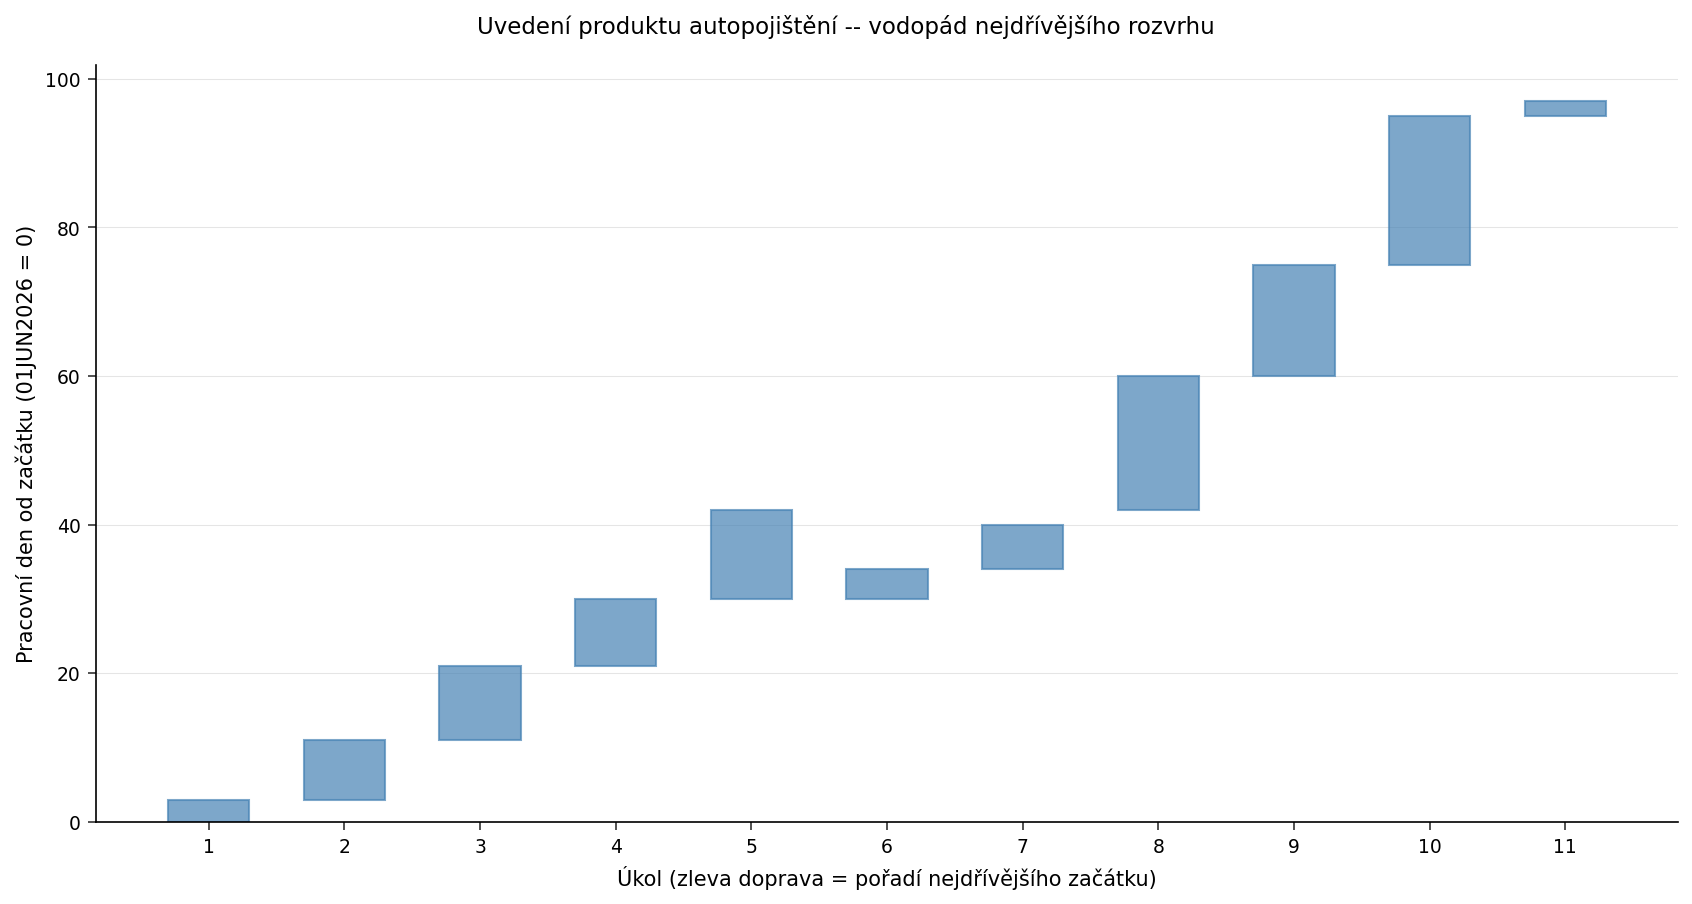

In [8]:
data gantt; NASTAVIT sched_es;
   ord = es;          /* číselné x = pořadí nejdřívějšího začátku */
SPUSTIT;
PROCEDURA ŘADIT data=gantt; PODLE ord activity; SPUSTIT;
data gantt; NASTAVIT gantt; ax = _n_; SPUSTIT;   /* kompaktní index x 1..11 */

ODS GRAPHICS ON / IMAGENAME='gantt' WIDTH=820px HEIGHT=440px;
NÁZEV 'Uvedení produktu autopojištění -- vodopád nejdřívějšího rozvrhu';
PROCEDURA SGPLOT data=gantt;
   highlow x=ax LOW=es HIGH=ef / type=bar barwidth=0.7;
   XAXIS ŠTÍTEK='Úkol (zleva doprava = pořadí nejdřívějšího začátku)'
         integer VALUES=(1 TO 11 PODLE 1);
   YAXIS ŠTÍTEK='Pracovní den od začátku (01JUN2026 = 0)' grid;
SPUSTIT;
ODS GRAPHICS OFF;

Při čtení zleva doprava sloupce plynule stoupají po kritickém řetězci. Dva úkoly, jejichž sloupce narušují schodiště -- začínají níže než vrchol předchozího sloupce -- jsou rate filing a approval, aktivity, které nesou rezervu.

## Celková rezerva podle úkolu

Vykreslení celkové rezervy každého úkolu činí kritickou cestu nepřehlédnutelnou: každý kritický úkol leží na nule a pouze dva regulatorní úkoly se nad ni zvedají.

                                  Celková rezerva podle úkolu (0 = na kritické cestě)                                   




NOTE: ODS Graphics is ON (width=820px, height=380px, format=SVG).
NOTE: Option TITLE changed to Celková rezerva podle úkolu (0 = na kritické cestě).
NOTE: PROC SGPLOT data=sched_es

NOTE: PROC SGPLOT output written to: ./ods_output/float.svg
NOTE: ODS Graphics is OFF.


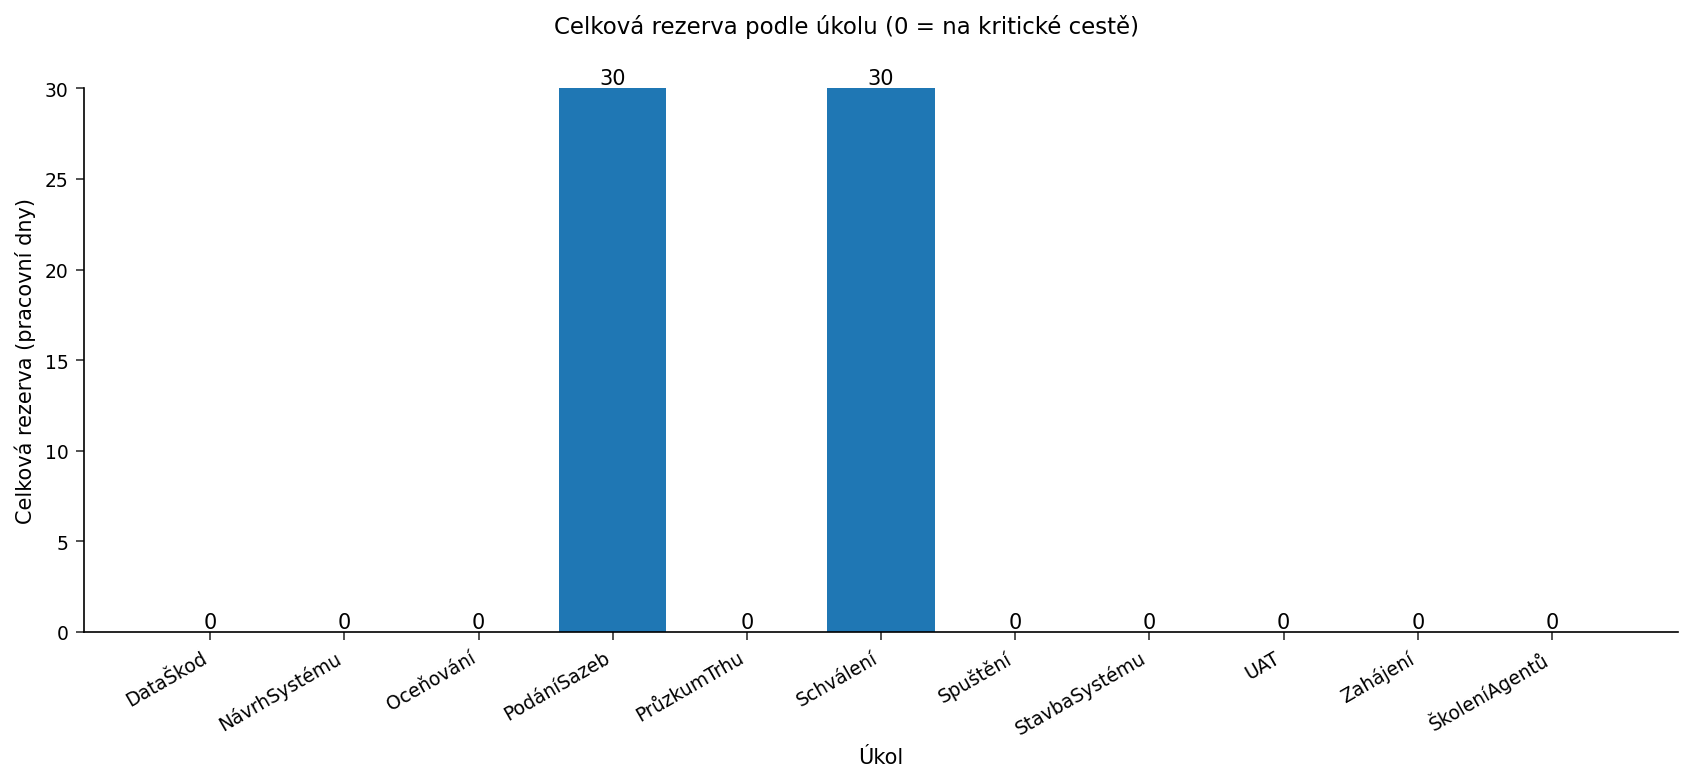

In [9]:
ODS GRAPHICS ON / IMAGENAME='float' WIDTH=820px HEIGHT=380px;
NÁZEV 'Celková rezerva podle úkolu (0 = na kritické cestě)';
PROCEDURA SGPLOT data=sched_es;
   VBAR activity / RESPONSE=tfloat DATALABEL;
   XAXIS ŠTÍTEK='Úkol' fitpolicy=rotatethin;
   YAXIS ŠTÍTEK='Celková rezerva (pracovní dny)';
SPUSTIT;
ODS GRAPHICS OFF;

## Zatížení zdrojů podle nejdřívějšího rozvrhu

Kromě časování soutěží plán o dva specializované fondy. Rozvinutí každého úkolu přes pracovní dny, které zabírá, a sečtení denní poptávky dává profil zatížení zdrojů -- kolik pojistných matematiků a vývojářů plán potřebuje každý den, pokud každý úkol začne co nejdříve. Špička je největší kapacita, kterou program kdy najednou vyžaduje.

                                  Špičkové denní zatížení zdrojů (nejdřívější rozvrh)                                   

                                                  The MEANS Procedure

 Variable    Label                    Maximum
 --------------------------------------------
 ACTUARIES   Pojistní matematici            3
 DEVELOPERS  Vývojáři                       3
 --------------------------------------------

                        Denní zatížení pojistných matematiků a vývojářů při nejdřívějším rozvrhu                        




NOTE: DATA load

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 10 rows from sched.
NOTE: Wrote load (105 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: Output dataset rprofile has 90 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=rprofile

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 90 rows from rprofile.
NOTE: Wrote rprofile (90 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: Option TITLE changed to Špičkové denní zatížení zdrojů (nejdřívější rozvrh).
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: ODS Graphics is ON (width=820px, height=360px, format=SVG).
NOTE: Option TITLE changed to Denní zatížení pojistných matematiků a vývojářů při nejdřívějším rozvrhu.
NOTE: PROC SGPLOT data=rprofile

NOTE: PROC SGPLOT output written to: ./ods_output/resload.svg
NOTE: ODS Graphics is OFF.


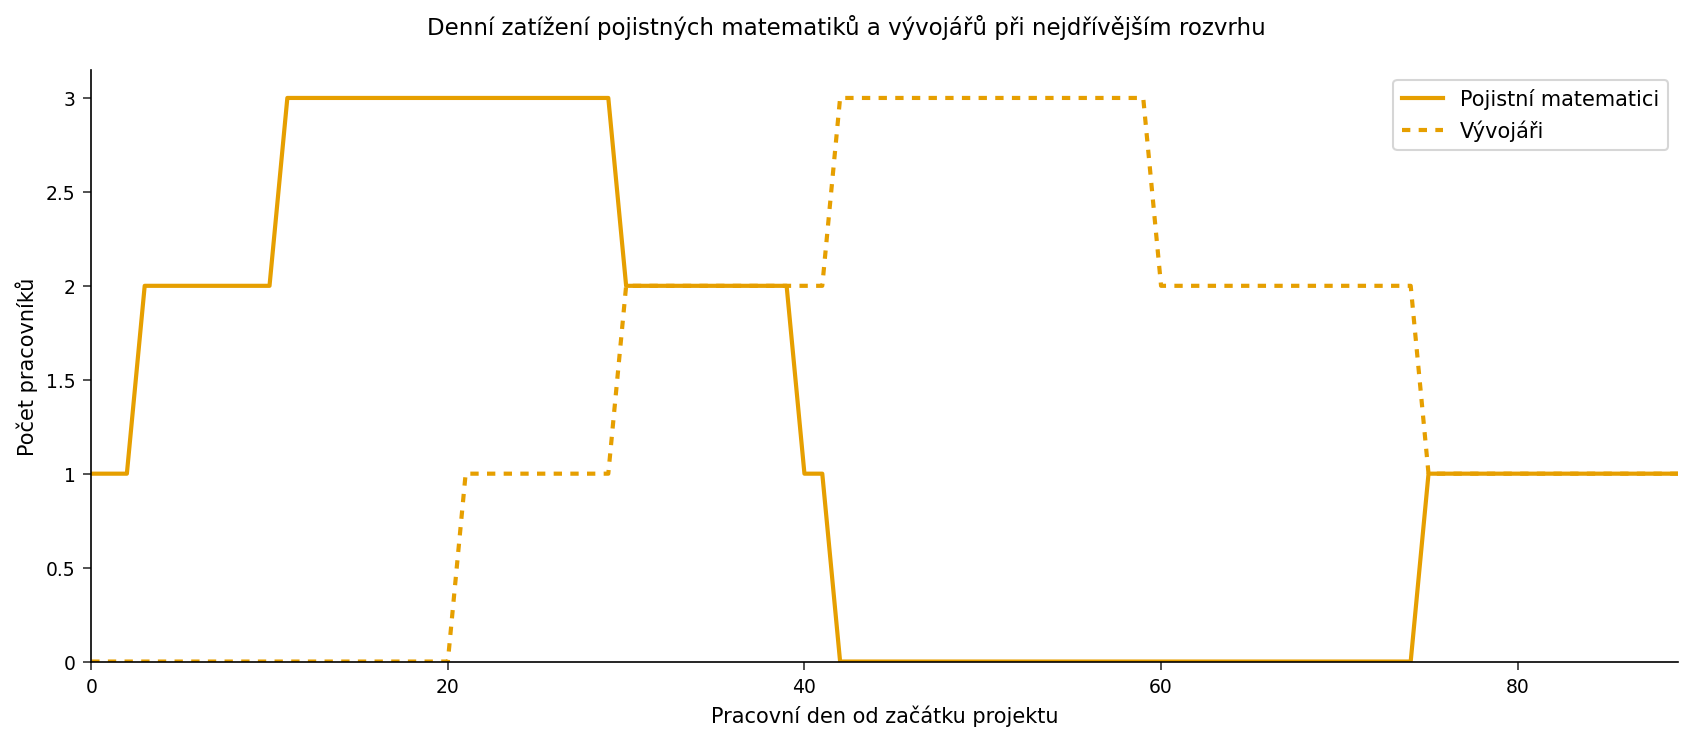

In [10]:
data LOAD;
   NASTAVIT sched;
   OPAKUJ d = es TO ef-1;
      day = d;
      a_use = actuary;
      d_use = developer;
      VÝSTUP;
   KONEC;
   PONECHAT day a_use d_use;
SPUSTIT;

PROCEDURA PRŮMĚRY data=LOAD NOPRINT NWAY;
   TŘÍDA day;
   PROMĚNNÁ a_use d_use;
   VÝSTUP out=rprofile(ODSTRANIT=_type_ _freq_)
          sum(a_use)=actuaries sum(d_use)=developers;
SPUSTIT;
PROCEDURA ŘADIT data=rprofile; PODLE day; SPUSTIT;

NÁZEV 'Špičkové denní zatížení zdrojů (nejdřívější rozvrh)';
PROCEDURA PRŮMĚRY data=rprofile MAX maxdec=0;
   PROMĚNNÁ actuaries developers;
   ŠTÍTEK actuaries='Pojistní matematici' developers='Vývojáři';
SPUSTIT;

ODS GRAPHICS ON / IMAGENAME='resload' WIDTH=820px HEIGHT=360px;
NÁZEV 'Denní zatížení pojistných matematiků a vývojářů při nejdřívějším rozvrhu';
PROCEDURA SGPLOT data=rprofile;
   SERIES x=day y=actuaries  /
          LINEATTRS=(thickness=2) legendlabel='Pojistní matematici';
   SERIES x=day y=developers /
          LINEATTRS=(thickness=2 pattern=shortdash)
          legendlabel='Vývojáři';
   XAXIS ŠTÍTEK='Pracovní den od začátku projektu';
   YAXIS ŠTÍTEK='Počet pracovníků' MIN=0;
   keylegend / location=inside position=topright;
SPUSTIT;
ODS GRAPHICS OFF;

## Interpretace výsledků

- **Datum uvedení určuje větev sestavení, nikoli regulatorní větev.** Kritická cesta vede Kickoff -> Market research -> Loss-data assembly -> Pricing -> System design -> System build -> UAT -> Agent training -> Launch, s makespanem 97 pracovních dní (konec 13OCT2026). Každý z těchto úkolů má nulovou rezervu, takže jakékoli zpoždění na nich posune uvedení o stejný počet dní.

- **Regulatorní větev má měsíc vůle.** Rate filing a approval nesou každý 30 pracovních dní celkové rezervy. Po dokončení oceňování mohou začít až ve svých nejpozdějších termínech začátku a přesto se včas napojit zpět na školení agentů, protože paralelní větev sestavení systému (system design -> system build -> UAT) je delší ze dvou cest napájejících uvedení. V plánovacích pojmech zde podání *není* svazující omezení -- tím je sestavení systému pojistných smluv.

- **Poptávka po specialistech vrcholí v různých fázích.** Profil zatížení ukazuje, že poptávka po pojistných matematicích vrcholí brzy (přes oceňování) a poptávka po vývojářích později (přes sestavení systému), přičemž každá dosahuje maxima tří lidí denně. Protože obě špičky spadají do různých fází, plán může obsadit malý, sekvenční tým specialistů -- program nepotřebuje svůj maximální počet pojistných matematiků a vývojářů současně.

**Obchodní závěr.** CPM promění seznam úkolů uvedení v akceschopný rozvrh: identifikuje aktivity větve sestavení, které pojistitel musí ochránit, aby stihl 13OCT2026, kvantifikuje měsíc vůle dostupný na regulatorním podání a ukazuje, že rozložené špičky pojistných matematiků a vývojářů umožňují štíhlému týmu specialistů plán dodat.

*Poznámka k implementaci:* SAS to počítá pomocí PROC CPM (SAS/OR). Jenner dosahuje stejného výsledku kritické cesty s dopředným/zpětným průchodem pomocí PROC OPTMODEL řešením dvou úloh o nejdelší cestě, které jsou základem této metody.